|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>Model 2: Position embedding, layernorm, tied output, temperature<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
# GPT-4's tokenizer
#!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

# Hyperparameters

In [3]:
# data hyperparameters
seq_len = 8 # aka context window
stride = 2

# model hyperparameters
embed_dim = 2**6 # 64

# training hyperparameters
batch_size = 5

# Get data

In [4]:
# tokenize the text
# note that we need torch tensors!
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

43053

### DataLoader

In [5]:
# create a class for a dataset (note: batching is done by the DataLoader, not in the dataset)
class tokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []

    # overlapping sequences of seq_len
    for i in range(0,len(tokens)-seq_len,stride):

      # get c tokens and append to the lists
      self.inputs.append( tokens[i   : i+seq_len])
      self.targets.append(tokens[i+1 : i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

# create an instance!
token_dataset = tokenDataset(tmTokens,seq_len,stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601,   881]),
 tensor([   38,   469, 37725,   220,  1758, 17601,   881,  8731]))

# The model

In [6]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # embeddings matrices
    self.embedding = nn.Embedding(tokenizer.n_vocab,embed_dim)
    self.positions = nn.Embedding(seq_len,embed_dim) #n

    # nonlinearity and layernorm
    self.gelu = nn.GELU()
    self.layernorm  = nn.LayerNorm(embed_dim) #n

    # the final output layer is tied to the token embeddings
    self.finalLinear = nn.Linear(embed_dim,tokenizer.n_vocab,bias=False)
    self.finalLinear.weight = nn.Parameter(self.embedding.weight) #n



  def forward(self,tokx):

    # create the token+position embedding
    token_embed = self.embedding(tokx)
    posit_embed = self.positions(torch.arange(tokx.shape[-1])) #n [numtokens, embedding_dims]

    # their sum is the output of the embeddings (the addition will broadcast for batch>1)
    x = token_embed + posit_embed #n [batch, numtokens, embedding_dims]

    # layernorm before linear layer
    x = self.layernorm(x) #n

    # forward pass
    x = self.gelu(x) # note: full GPT models don't have gelu before the final unembeddings
    x = self.finalLinear(x) / np.sqrt(embed_dim)
    return x

  def generate(self,tokx,temperature=1,n_new_tokens=50): #n

    # tokx is batch X tokens

    for _ in range(n_new_tokens):

      # get predictions, but only from the past seq_len tokens
      x = self(tokx[:,-seq_len:]) #n [batch, seq_len, n_vocab]

      # extract the final token to predict the next
      x = x[:,-1,:] # [batch, n_vocab]

      # apply softmax to get probability values over all tokens in the vocab - with temperature
      probs = F.softmax(x/temperature,dim=-1) #n [batch, n_vocab]

      # probabilistically sample from the distribution
      tokx_next = torch.multinomial(probs,num_samples=1) # [batch, 1]

      # append
      tokx = torch.cat( (tokx,tokx_next),dim=1) # [batch, (tokens+1)]
    return tokx


# Create a model instance and test

In [7]:
m = Model()
X,y = token_dataset[4]
out = m(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


In [8]:
print(f'Expected loss for random weights: {-np.log(1/tokenizer.n_vocab):.3f}')
print(f'Observed mean log-softmax output: {torch.mean(-F.log_softmax(out.detach(),dim=-1)):.3f}')
print(f'Cross-entropy loss from pytorch:  {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}')

Expected loss for random weights: 11.516
Observed mean log-softmax output: 11.734
Cross-entropy loss from pytorch:  11.690


# Demo of position+token embeddings

In [9]:
# broadcasting the token+position embeddings in small matrices
T = torch.ones(2,3,4) # [batch, numtokens, embedding_dims]
P = torch.arange(4)

print(f'Token embeddings matrix ({T.shape}):')
print(T)

print(f'\nPosition embeddings matrix ({P.shape}):')
print(P)

print(f'\nTheir sum: ({(T+P).shape}):')
print(T+P)

Token embeddings matrix (torch.Size([2, 3, 4])):
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

Position embeddings matrix (torch.Size([4])):
tensor([0, 1, 2, 3])

Their sum: (torch.Size([2, 3, 4])):
tensor([[[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]],

        [[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]]])


In [10]:
# again using the real weights from the model
P = m.positions(torch.arange(seq_len))
T = m.embedding(X)

print(f'Token embeddings matrix ({T.shape})')
print(f'\nPosition embeddings matrix ({P.shape})')
print(f'\nTheir sum: ({(T+P).shape})')

Token embeddings matrix (torch.Size([8, 64]))

Position embeddings matrix (torch.Size([8, 64]))

Their sum: (torch.Size([8, 64]))


# Visualizing the model output

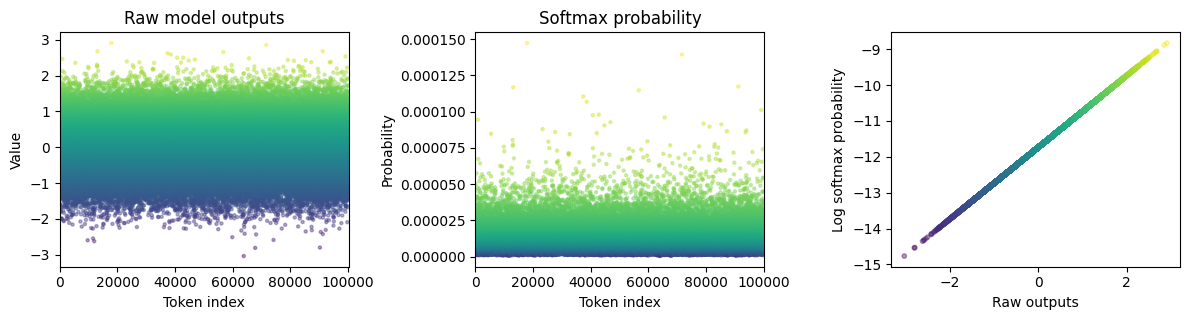

In [11]:
# visualize the softmax output
out = m(X)
final = out[-1,:].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()


# create a figure
_,axs = plt.subplots(1,3,figsize=(12,3.3))

# show the logits (raw logit coloring throughout)
axs[0].scatter(range(len(final)),final,s=5,marker='o',c=final,alpha=.4)
axs[0].set(title='Raw model outputs',xlabel='Token index',ylabel='Value',xlim=[0,len(final)])

# the softmaxified logits (probabilities)
axs[1].scatter(range(len(final)),softmaxFinal,s=5,marker='o',c=final,alpha=.4)
axs[1].set(title='Softmax probability',xlabel='Token index',ylabel='Probability',xlim=[0,len(final)])

# their relation
axs[2].scatter(final,torch.log(softmaxFinal),s=10,marker='o',c=final,alpha=.4)
axs[2].set(xlabel='Raw outputs',ylabel='Log softmax probability')

plt.tight_layout()
plt.show()

# Generate text in batches

In [12]:
# also need a dataloader
dataloader = DataLoader(
                token_dataset,
                batch_size = batch_size,
                shuffle    = True,
                drop_last  = True
            )

# let's have a look at the indices
X,y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens):')
print(X)

Inputs (5 batches X 8 tokens):
tensor([[  757,  2231,   856, 27129,    13,   578,  3892,  2466],
        [  279, 17680, 16549,    11,  1054,  4636,   433,   753],
        [  281,  4114,    13,  1054, 75471,  2476,   279,  4212],
        [    8,   323,   813, 55061,  1263,   488, 18304, 33672],
        [11746,    13,  5810,   374,   264,  5526, 12624, 13861]])


In [13]:
# get model outputs (logits)
out = m(X)
print(out.shape) # batch X tokens X vocab
print(out)

torch.Size([5, 8, 100277])
tensor([[[-2.0190e-01, -1.5598e-01, -8.7791e-01,  ..., -1.4948e-01,
           2.4131e-01,  2.3196e-01],
         [-6.9992e-01,  1.2453e+00,  3.0501e-01,  ...,  3.9293e-02,
          -8.0438e-01,  2.6989e-01],
         [ 6.4624e-01,  3.7659e-01, -3.2623e-01,  ..., -5.3222e-01,
          -9.5904e-01,  4.1579e-01],
         ...,
         [ 5.3392e-01, -5.0759e-01, -4.0013e-01,  ...,  3.4597e-01,
          -6.7115e-01, -1.5239e-03],
         [ 6.6661e-02,  8.5859e-01,  6.9046e-01,  ..., -1.1160e-01,
          -3.2043e-01, -3.4583e-01],
         [ 1.9386e-01, -1.1228e+00, -1.1421e+00,  ..., -4.5491e-01,
           8.9495e-01,  1.2101e+00]],

        [[-1.1178e-01,  3.9094e-01,  1.5272e-01,  ...,  7.3755e-01,
          -5.5054e-01, -2.0402e-01],
         [-1.2732e-01, -2.8153e-02, -1.4619e+00,  ...,  5.2628e-01,
          -4.1153e-01, -1.2261e+00],
         [ 6.7637e-01, -7.9346e-02, -3.7467e-01,  ..., -3.5799e-01,
          -2.9283e-01, -1.6513e-01],
         ...

In [14]:
# generate some data
gen_tokens = m.generate(X,temperature=1.3,n_new_tokens=8)
print(gen_tokens.shape) # batch X (tokens+n_new_tokens)

torch.Size([5, 16])


In [15]:
# repeat multiple times from the same starting point
for batchtok in gen_tokens:
  print('\n--- NEXT SAMPLE: ---\n')
  print(tokenizer.decode(batchtok.tolist()))


--- NEXT SAMPLE: ---

 me put my difficulties. The several big_tf.extension:]

 NEC(coeffs animươaddOn

--- NEXT SAMPLE: ---

 the Psychologist, “though it’s_J timeval swagger.fastjsonawait'I(CharINLINE

--- NEXT SAMPLE: ---

 pensive. “Clearly,” the Time Murrayと[W$dgetic viewWillAppear_anchor Lose

--- NEXT SAMPLE: ---

) and his fecundity.

“You Fortressowed)));

 catsIVA aparehausen Flyers

--- NEXT SAMPLE: ---

 Space. Here is a popular scientific diagram CFygmuch<Boolean iii(Logger
 London
